# Case 01

corridor,scenario,method,distance_nm,speed_kn,days
NSR,NSR_VAR3_NX_ASTAR,A* (NX),6894.5,12.5,22.98
NSR,NSR_VAR1_NX_ASTAR,A* (NX),7026.6,12.5,23.42
NSR,NSR_VAR2_NX_ASTAR,A* (NX),7116.1,12.5,23.72
SUEZ,SUEZ_VAR3_NX_ASTAR,A* (NX),10350.9,14.5,29.74
SUEZ,SUEZ_VAR2_NX_ASTAR,A* (NX),10434.7,14.5,29.98
SUEZ,SUEZ_VAR1_NX_ASTAR,A* (NX),10660.9,14.5,30.63


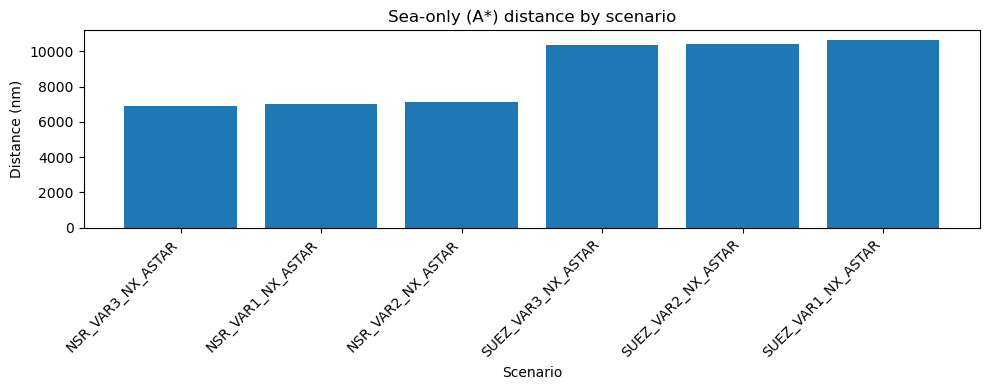

            min    max   mean  count
corridor                            
NSR       6,894  7,116  7,012      3
SUEZ     10,351 10,661 10,482      3


In [1]:
# --- Case Study 1: Corridor geometries and distance comparison ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Compile your scenario results into a single DataFrame.
#    I've prefilled the NSR and SUEZ rows you reported. 
#    --> TODO: append your CAPE_VAR1/2/3 rows below with the same fields.

rows = [
    # corridor, scenario, method, distance_nm, speed_kn, hours, days, fuel_t, fuel_me_t, fuel_aux_t, co2_t, legs
    ("NSR","NSR_VAR1_NX_ASTAR","A* (NX)",7026.586688,12.5,562.126935,23.421956,778.295971,663.622076,114.673895,2423.613653,7),
    ("NSR","NSR_VAR2_NX_ASTAR","A* (NX)",7116.083162,12.5,569.286653,23.720277,788.208998,672.074521,116.134477,2454.482820,6),
    ("NSR","NSR_VAR3_NX_ASTAR","A* (NX)",6894.487575,12.5,551.559006,22.981625,763.664086,651.146049,112.518037,2378.049964,6),
    ("SUEZ","SUEZ_VAR1_NX_ASTAR","A* (NX)",10660.944813,14.5,735.237573,30.634899,1504.828714,1354.840249,149.988465,4686.036615,6),
    ("SUEZ","SUEZ_VAR2_NX_ASTAR","A* (NX)",10434.683474,14.5,719.633343,29.984723,1472.891154,1326.085952,146.805202,4586.583054,6),
    ("SUEZ","SUEZ_VAR3_NX_ASTAR","A* (NX)",10350.856065,14.5,713.852142,29.743839,1461.058630,1315.432793,145.625837,4549.736573,6),
    # ---- TODO: insert your Cape results here ----
    # Example placeholders (replace with your actual outputs):
    # ("CAPE","CAPE_VAR1_NX_ASTAR","A* (NX)", 0.0, 14.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6),
    # ("CAPE","CAPE_VAR2_NX_ASTAR","A* (NX)", 0.0, 14.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6),
    # ("CAPE","CAPE_VAR3_NX_ASTAR","A* (NX)", 0.0, 14.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6),
]

df = pd.DataFrame(rows, columns=["corridor","scenario","method","distance_nm","speed_kn","hours","days","fuel_t","fuel_me_t","fuel_aux_t","co2_t","legs"])

# sanity: compute hours if missing; recompute days from hours
df["hours_calc"] = df["distance_nm"] / df["speed_kn"] * 1.0
df["hours"] = df["hours"].fillna(df["hours_calc"])
df["days"] = df["hours"] / 24.0

# 2) Table 1: distance by corridor/variant (sorted)
tbl1 = df.sort_values(["corridor","distance_nm"])[["corridor","scenario","method","distance_nm","speed_kn","days"]]
display(tbl1.style.format({"distance_nm":"{:.1f}","speed_kn":"{:.1f}","days":"{:.2f}"}).hide(axis="index"))

# 3) Figure 1: bar plot of distances by scenario
plt.figure(figsize=(10,4))
ax = plt.gca()
df_sorted = df.sort_values("distance_nm")
ax.bar(df_sorted["scenario"], df_sorted["distance_nm"])
ax.set_xlabel("Scenario")
ax.set_ylabel("Distance (nm)")
ax.set_title("Sea-only (A*) distance by scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4) Corridor distance summary
summary = df.groupby("corridor")["distance_nm"].agg(["min","max","mean","count"]).sort_values("mean")
print(summary.to_string(float_format=lambda x: f"{x:,.0f}"))
